In [1]:
from google.colab import files
files.upload()

Saving crops (2).txt to crops (2).txt


{'crops (2).txt': b'Rice,Kharif,10,800,120,4500 \r\nWheat,Rabi,8,300,90,2800\r\nMaize,Kharif,6,600,100,3200 \r\nCotton,Kharif,12,700,140,3600 \r\nSugarcane,Annual,15,1200,200,9000 \r\nPulses,Rabi,5,250,60,1100 \r\nGroundnut,Kharif,7,500,80,1800\r\nMustard,Rabi,6,300,70,1500 \r\nBarley,Rabi,7,280,65,1600 \r\nSorghum,Kharif,8,550,90,2400 \r\nMillet,Kharif,5,400,60,1400 Sunflower,Kharif,6,450,85,1700 Potato,Rabi,4,350,120,3000 \r\nOnion,Rabi,5,320,100,2800 \r\nTomato,Kharif,4,500,110,2600 \r\nChickpea,Rabi,6,260,70,1400 \r\nPeanut,Kharif,7,480,85,1900 \r\nMaize,Rabi,6,320,95,2900 \r\nRice,Rabi,9,450,130,4200'}

In [10]:
# Agricultural Data Analysis Project

# ---------- Function Definitions ----------

def load_data(filename):
    """Reads crop data from a file and returns a list of dictionaries,
    handling cases where multiple crop records might be on a single line."""
    crops = []
    with open(filename, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue # Skip empty lines

            # Attempt to split the line into potential crop data segments
            segments = line.split(",")

            # Each crop record is expected to have 6 fields
            if len(segments) % 6 == 0 and len(segments) > 0:
                num_crops_in_line = len(segments) // 6
                for i in range(num_crops_in_line):
                    start_idx = i * 6
                    end_idx = start_idx + 6
                    crop_data = segments[start_idx:end_idx]

                    try:
                        crop = {
                            "name": crop_data[0],
                            "season": crop_data[1],
                            "area": float(crop_data[2]),
                            "rainfall": float(crop_data[3]),
                            "fertilizer": float(crop_data[4]),
                            "yield": float(crop_data[5])
                        }
                        crops.append(crop)
                    except ValueError as e:
                        print(f"Warning: Could not parse crop record '{','.join(crop_data)}' due to error: {e}. Skipping.")
                    except IndexError as e:
                        print(f"Warning: Malformed crop record '{','.join(crop_data)}' due to error: {e}. Skipping.")
            else:
                print(f"Warning: Skipping malformed line (not a multiple of 6 fields): '{line}'")
    return crops


def calculate_yield_per_area(crop):
    """Returns yield per unit area"""
    return crop["yield"] / crop["area"]


def display_crops(crops):
    """Displays all crop records"""
    print("\nCrop Records:")
    for crop in crops:
        ypa = calculate_yield_per_area(crop)
        print(crop["name"], "-", crop["season"], "- Yield/Area:", round(ypa, 2))


def find_highest_and_lowest_yield(crops):
    """Finds crops with highest and lowest yield per area"""
    highest = crops[0]
    lowest = crops[0]

    for crop in crops:
        if calculate_yield_per_area(crop) > calculate_yield_per_area(highest):
            highest = crop
        if calculate_yield_per_area(crop) < calculate_yield_per_area(lowest):
            lowest = crop

    return highest, lowest


def seasonal_summary(crops):
    """Generates seasonal yield summary using dictionary"""
    summary = {}

    for crop in crops:
        season = crop["season"]
        ypa = calculate_yield_per_area(crop)

        if season not in summary:
            summary[season] = []
        summary[season].append(ypa)

    return summary


def write_report(filename, crops, highest, lowest, summary):
    """Writes analysis results to output file"""
    file = open(filename, "w")

    file.write("Agricultural Data Analysis Report\n\n")

    file.write("Crop Yield per Unit Area:\n")
    for crop in crops:
        ypa = calculate_yield_per_area(crop)
        file.write(crop["name"] + ": " + str(round(ypa, 2)) + "\n")

    file.write("\nHighest Yield Crop:\n")
    file.write(highest["name"] + "\n")

    file.write("\nLowest Yield Crop:\n")
    file.write(lowest["name"] + "\n")

    file.write("\nSeasonal Average Yield:\n")
    for season in summary:
        avg = sum(summary[season]) / len(summary[season])
        file.write(season + ": " + str(round(avg, 2)) + "\n")

    file.close()


# ---------- Main Program ----------

def main():
    input_file = "crops (2).txt"
    output_file = "analysis_report.txt"

    crops = load_data(input_file)

    for crop in crops:
      print(crop)

    for crop in crops:
      for key, value in crop.items():
        print(f"{key}: {value}")
      print("-----")


    display_crops(crops)

    highest, lowest = find_highest_and_lowest_yield(crops)

    summary = seasonal_summary(crops)

    print("\nSeason-wise Yield per Area:")
    for season, values in summary.items():
        print(season, ":", values)
    print("\nHighest Yield Crop:", highest["name"])
    print("Lowest Yield Crop:", lowest["name"])

    write_report(output_file, crops, highest, lowest, summary)

    print("\nAnalysis complete. Report written to", output_file)

main()

{'name': 'Rice', 'season': 'Kharif', 'area': 10.0, 'rainfall': 800.0, 'fertilizer': 120.0, 'yield': 4500.0}
{'name': 'Wheat', 'season': 'Rabi', 'area': 8.0, 'rainfall': 300.0, 'fertilizer': 90.0, 'yield': 2800.0}
{'name': 'Maize', 'season': 'Kharif', 'area': 6.0, 'rainfall': 600.0, 'fertilizer': 100.0, 'yield': 3200.0}
{'name': 'Cotton', 'season': 'Kharif', 'area': 12.0, 'rainfall': 700.0, 'fertilizer': 140.0, 'yield': 3600.0}
{'name': 'Sugarcane', 'season': 'Annual', 'area': 15.0, 'rainfall': 1200.0, 'fertilizer': 200.0, 'yield': 9000.0}
{'name': 'Pulses', 'season': 'Rabi', 'area': 5.0, 'rainfall': 250.0, 'fertilizer': 60.0, 'yield': 1100.0}
{'name': 'Groundnut', 'season': 'Kharif', 'area': 7.0, 'rainfall': 500.0, 'fertilizer': 80.0, 'yield': 1800.0}
{'name': 'Mustard', 'season': 'Rabi', 'area': 6.0, 'rainfall': 300.0, 'fertilizer': 70.0, 'yield': 1500.0}
{'name': 'Barley', 'season': 'Rabi', 'area': 7.0, 'rainfall': 280.0, 'fertilizer': 65.0, 'yield': 1600.0}
{'name': 'Sorghum', 'seas

Correlation between Fertilizer and Yield: 0.96


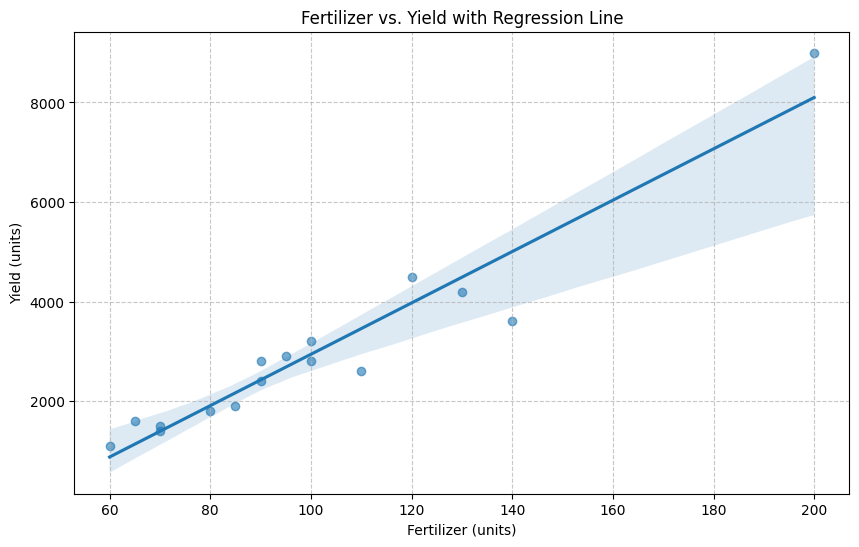

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract fertilizer and yield data from the crops list
fertilizer_data = [crop['fertilizer'] for crop in crops]
yield_data = [crop['yield'] for crop in crops]

# Create a DataFrame for easier correlation calculation
df_correlation = pd.DataFrame({
    'Fertilizer': fertilizer_data,
    'Yield': yield_data
})

# Calculate the Pearson correlation coefficient
correlation = df_correlation['Fertilizer'].corr(df_correlation['Yield'])

print(f"Correlation between Fertilizer and Yield: {correlation:.2f}")

# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Fertilizer', y='Yield', data=df_correlation, scatter_kws={'alpha':0.6})
plt.title('Fertilizer vs. Yield with Regression Line')
plt.xlabel('Fertilizer (units)')
plt.ylabel('Yield (units)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot above visually represents the relationship between fertilizer usage and crop yield. The regression line indicates the general trend, and the correlation coefficient quantifies the strength and direction of this linear relationship.

In [13]:
# Agricultural Data Analysis Project

# ---------- Function Definitions ----------

def load_data(filename):
    """Reads crop data from a file and returns a list of dictionaries,
    handling cases where multiple crop records might be on a single line."""
    crops = []
    with open(filename, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue # Skip empty lines

            # Attempt to split the line into potential crop data segments
            segments = line.split(",")

            # Each crop record is expected to have 6 fields
            if len(segments) % 6 == 0 and len(segments) > 0:
                num_crops_in_line = len(segments) // 6
                for i in range(num_crops_in_line):
                    start_idx = i * 6
                    end_idx = start_idx + 6
                    crop_data = segments[start_idx:end_idx]

                    try:
                        crop = {
                            "name": crop_data[0],
                            "season": crop_data[1],
                            "area": float(crop_data[2]),
                            "rainfall": float(crop_data[3]),
                            "fertilizer": float(crop_data[4]),
                            "yield": float(crop_data[5])
                        }
                        crops.append(crop)
                    except ValueError as e:
                        print(f"Warning: Could not parse crop record '{','.join(crop_data)}' due to error: {e}. Skipping.")
                    except IndexError as e:
                        print(f"Warning: Malformed crop record '{','.join(crop_data)}' due to error: {e}. Skipping.")
            else:
                print(f"Warning: Skipping malformed line (not a multiple of 6 fields): '{line}'")
    return crops


def calculate_yield_per_area(crop):
    """Returns yield per unit area"""
    return crop["yield"] / crop["area"]


def display_crops(crops):
    """Displays all crop records"""
    print("\nCrop Records:")
    for crop in crops:
        ypa = calculate_yield_per_area(crop)
        print(crop["name"], "-", crop["season"], "- Yield/Area:", round(ypa, 2))


def find_highest_and_lowest_yield(crops):
    """Finds crops with highest and lowest yield per area"""
    highest = crops[0]
    lowest = crops[0]

    for crop in crops:
        if calculate_yield_per_area(crop) > calculate_yield_per_area(highest):
            highest = crop
        if calculate_yield_per_area(crop) < calculate_yield_per_area(lowest):
            lowest = crop

    return highest, lowest


def seasonal_summary(crops):
    """Generates seasonal yield summary using dictionary"""
    summary = {}

    for crop in crops:
        season = crop["season"]
        ypa = calculate_yield_per_area(crop)

        if season not in summary:
            summary[season] = []
        summary[season].append(ypa)

    return summary


def write_report(filename, crops, highest, lowest, summary):
    """Writes analysis results to output file"""
    file = open(filename, "w")

    file.write("Agricultural Data Analysis Report\n\n")

    file.write("Crop Yield per Unit Area:\n")
    for crop in crops:
        ypa = calculate_yield_per_area(crop)
        file.write(crop["name"] + ": " + str(round(ypa, 2)) + "\n")

    file.write("\nHighest Yield Crop:\n")
    file.write(highest["name"] + "\n")

    file.write("\nLowest Yield Crop:\n")
    file.write(lowest["name"] + "\n")

    file.write("\nSeasonal Average Yield:\n")
    for season in summary:
        avg = sum(summary[season]) / len(summary[season])
        file.write(season + ": " + str(round(avg, 2)) + "\n")

    file.close()


# ---------- Main Program ----------

def main():
    input_file = "crops (2).txt"
    output_file = "analysis_report.txt"

    crops = load_data(input_file)

    # The previous print statements for individual crops are removed for brevity.
    # display_crops(crops)

    highest, lowest = find_highest_and_lowest_yield(crops)

    summary = seasonal_summary(crops)

    # The previous print statements for season-wise yield, highest, and lowest crops are removed for brevity.
    # print("\nSeason-wise Yield per Area:")
    # for season, values in summary.items():
    #     print(season, ":", values)
    # print("\nHighest Yield Crop:", highest["name"])
    # print("Lowest Yield Crop:", lowest["name"])

    write_report(output_file, crops, highest, lowest, summary)

    # print("\nAnalysis complete. Report written to", output_file)
    return crops, summary

crops, summary = main()

/tmp/ipython-input-4149937754.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasons, y=avg_yields, palette='viridis')


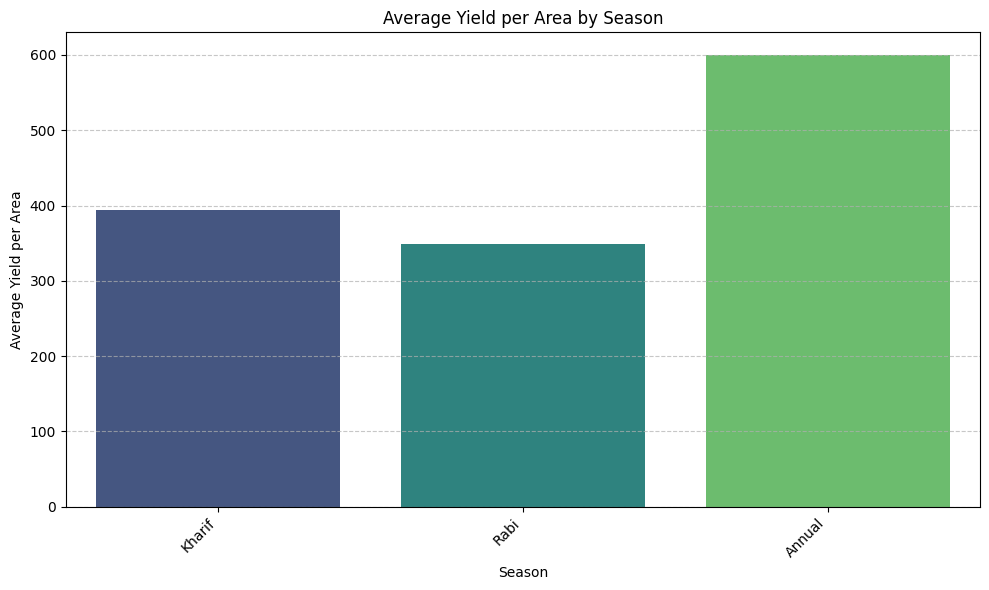

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average yield per season
seasonal_avg_yield = {season: sum(values) / len(values) for season, values in summary.items()}

# Prepare data for plotting
seasons = list(seasonal_avg_yield.keys())
avg_yields = list(seasonal_avg_yield.values())

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=seasons, y=avg_yields, palette='viridis')
plt.title('Average Yield per Area by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield per Area')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-68013808.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='yield_per_area', data=df_crop_yield, palette='viridis')


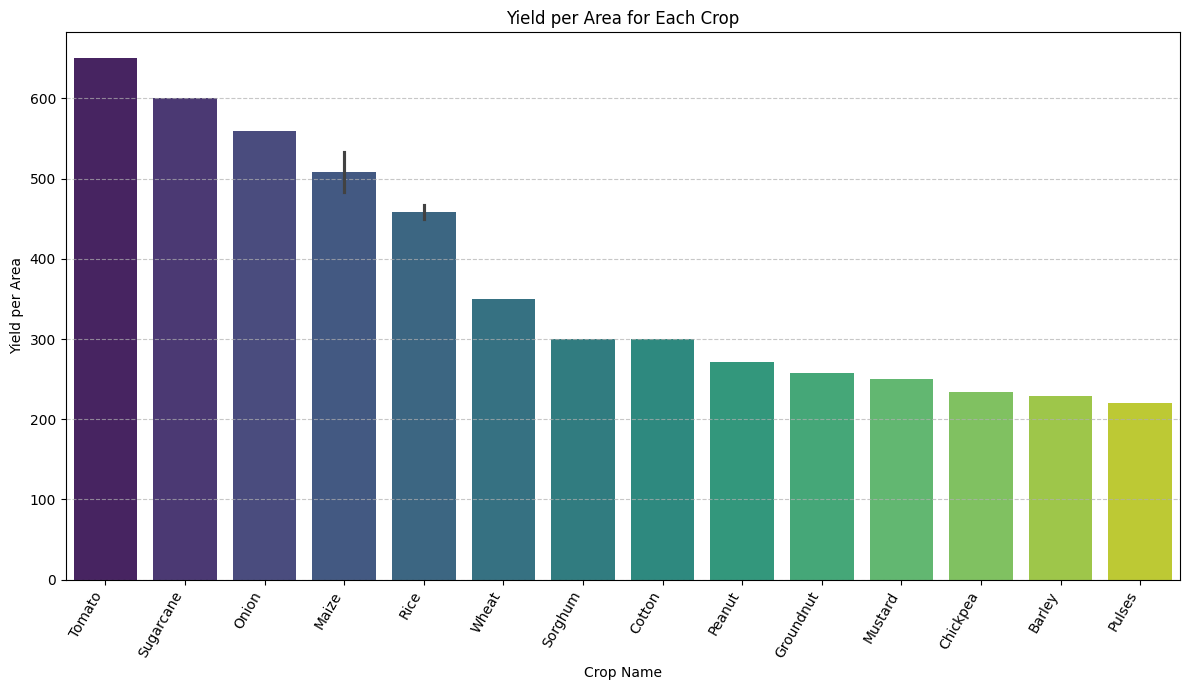

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate 'Yield per Area' for each crop
# Ensure 'crops' is available, it should be from the previous execution of main()

if 'crops' not in locals():
    print("Error: 'crops' variable not found. Please run the main function first.")
else:
    crop_yield_per_area = []
    for crop in crops:
        ypa = crop['yield'] / crop['area']
        crop_yield_per_area.append({
            'name': crop['name'],
            'yield_per_area': ypa
        })

    # Convert to DataFrame for easier plotting
    df_crop_yield = pd.DataFrame(crop_yield_per_area)

    # Sort for better visualization (optional)
    df_crop_yield = df_crop_yield.sort_values(by='yield_per_area', ascending=False)

    # Create the bar chart
    plt.figure(figsize=(12, 7))
    sns.barplot(x='name', y='yield_per_area', data=df_crop_yield, palette='viridis')
    plt.title('Yield per Area for Each Crop')
    plt.xlabel('Crop Name')
    plt.ylabel('Yield per Area')
    plt.xticks(rotation=60, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-2572509004.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Average Fertilizer', data=df_seasonal_fertilizer, palette='magma')


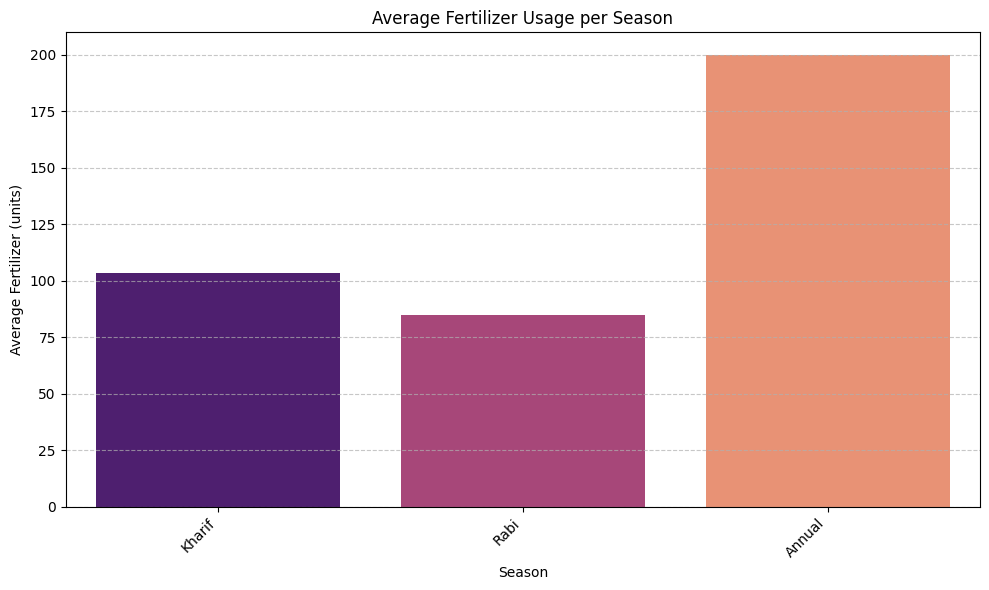

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for seasonal fertilizer analysis
if 'crops' not in locals():
    print("Error: 'crops' variable not found. Please run the main function first.")
else:
    seasonal_fertilizer_data = {}
    for crop in crops:
        season = crop['season']
        fertilizer = crop['fertilizer']

        if season not in seasonal_fertilizer_data:
            seasonal_fertilizer_data[season] = []
        seasonal_fertilizer_data[season].append(fertilizer)

    # Calculate average fertilizer per season
    seasonal_avg_fertilizer = {season: sum(values) / len(values) for season, values in seasonal_fertilizer_data.items()}

    # Convert to DataFrame for easier plotting
    df_seasonal_fertilizer = pd.DataFrame(list(seasonal_avg_fertilizer.items()), columns=['Season', 'Average Fertilizer'])

    # Create the bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Season', y='Average Fertilizer', data=df_seasonal_fertilizer, palette='magma')
    plt.title('Average Fertilizer Usage per Season')
    plt.xlabel('Season')
    plt.ylabel('Average Fertilizer (units)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

This bar chart illustrates the average fertilizer usage across different agricultural seasons. It helps in understanding if there are variations in fertilizer application based on the growing season, potentially influenced by crop types dominant in each season or specific seasonal requirements.

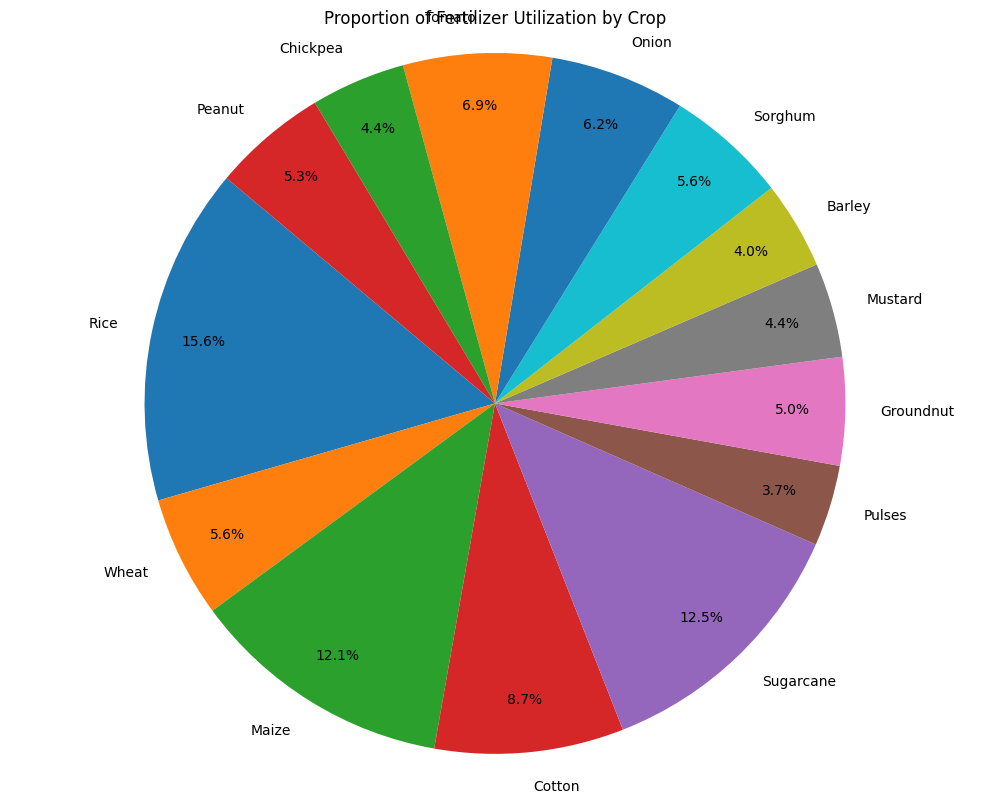

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for pie chart
# Assuming 'crops' list is available from previous execution
if 'crops' not in locals():
    print("Error: 'crops' variable not found. Please run the main function first.")
else:
    fertilizer_by_crop = {}
    for crop in crops:
        name = crop['name']
        fertilizer = crop['fertilizer']
        fertilizer_by_crop[name] = fertilizer_by_crop.get(name, 0) + fertilizer

    # Convert to a DataFrame for easier plotting
    df_fertilizer = pd.DataFrame(list(fertilizer_by_crop.items()), columns=['Crop', 'Total Fertilizer'])

    # Create the pie chart
    plt.figure(figsize=(10, 8))
    plt.pie(df_fertilizer['Total Fertilizer'], labels=df_fertilizer['Crop'], autopct='%1.1f%%', startangle=140, pctdistance=0.85)
    plt.title('Proportion of Fertilizer Utilization by Crop')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.tight_layout()
    plt.show()

The pie chart above illustrates the proportion of total fertilizer utilized by each crop. Each slice represents a crop, and its size corresponds to the percentage of the total fertilizer it accounts for, providing insight into fertilizer distribution among different crops.

This bar chart displays the 'Yield per Area' for each individual crop, allowing for a straightforward comparison of their productivity. Crops are sorted from highest to lowest yield per area.

The bar chart above visually represents the average yield per unit area for each season (Kharif, Rabi, and Annual). This allows for a quick comparison of productivity across different agricultural seasons.

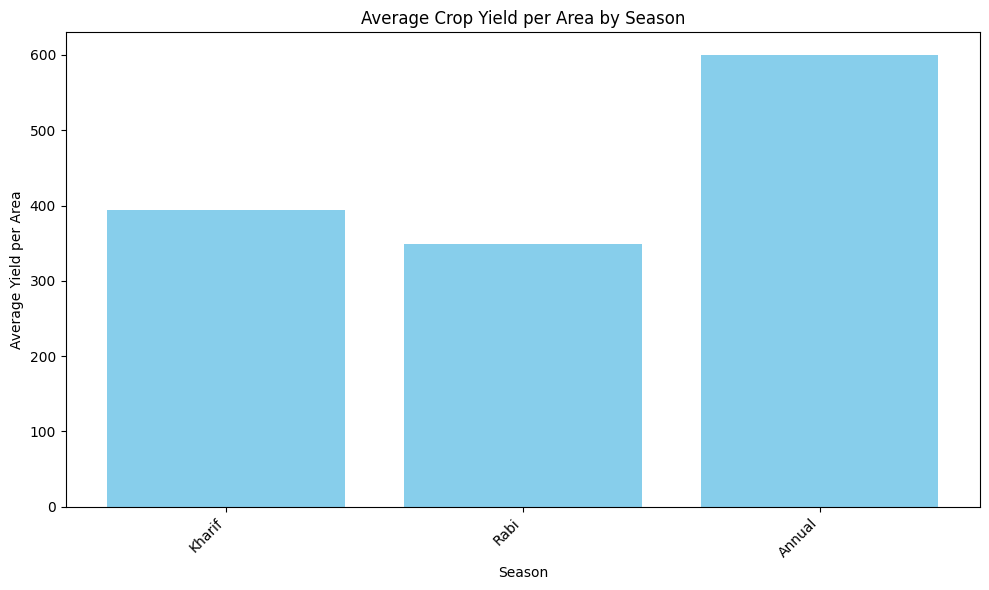

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Re-load data and calculate summary as the original `summary` variable was local to main()
input_file = "crops (2).txt"
crops = load_data(input_file)
summary = seasonal_summary(crops)

# Calculate average yield per season
average_yield_per_season = {}
for season, yields in summary.items():
    average_yield_per_season[season] = np.mean(yields)

# Prepare data for plotting
seasons = list(average_yield_per_season.keys())
avg_yields = list(average_yield_per_season.values())

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(seasons, avg_yields, color='skyblue')

# Add labels and title
plt.xlabel('Season')
plt.ylabel('Average Yield per Area')
plt.title('Average Crop Yield per Area by Season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Display the plot
plt.show()